In [1]:
import pandas as pd
from pathlib import Path

repo_root = Path(r"C:\Users\elois\OneDrive\Desktop\vitality-behaviour-analysis")

PRED_PATH = repo_root / "data" / "processed" / "weekly_predictions.parquet"

model_df = pd.read_parquet(PRED_PATH)

model_df.head()

,week,wed_points,active_days,max_day_points,date,weekly_points,ring_closed,feasible_2_days,predicted_prob,predicted_label
0,2014-12-27/2015-01-02,0,0,0,2015-01-02,0,0,0,0.001867,0
1,2015-01-03/2015-01-09,0,0,0,2015-01-09,0,0,0,0.001867,0
2,2015-01-10/2015-01-16,0,0,0,2015-01-16,0,0,0,0.001867,0
3,2015-01-24/2015-01-30,0,0,0,2015-01-30,0,0,0,0.001867,0
4,2015-01-31/2015-02-06,0,0,0,2015-02-06,0,0,0,0.001867,0


In [2]:
model_df[[
    "weekly_points",
    "ring_closed",
    "predicted_prob"
]].describe()

,weekly_points,ring_closed,predicted_prob
count,361.000000,361.000000,361.000000
mean,274.792244,0.088643,0.094111
std,365.378835,0.284622,0.173377
min,0.000000,0.000000,0.001867
25%,0.000000,0.000000,0.001867
50%,0.000000,0.000000,0.001867
75%,600.000000,0.000000,0.113147
max,1800.000000,1.000000,0.980689


In [3]:
from sklearn.metrics import roc_auc_score, brier_score_loss

y_true = model_df["ring_closed"]
y_prob = model_df["predicted_prob"]

roc_auc = roc_auc_score(y_true, y_prob)
brier = brier_score_loss(y_true, y_prob)

roc_auc, brier

(0.9339855623100304, 0.04590262910928172)

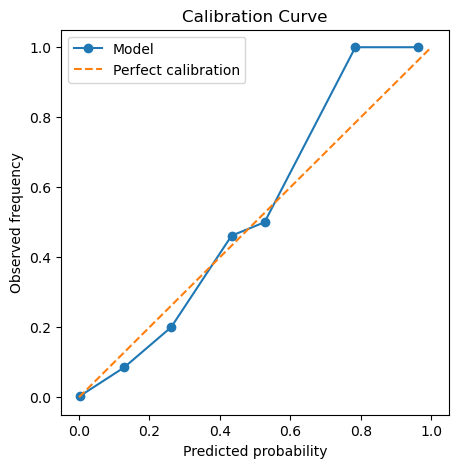

In [4]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)

plt.figure(figsize=(5,5))
plt.plot(mean_pred, frac_pos, marker="o", label="Model")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [5]:
import numpy as np

thresholds = np.linspace(0.1, 0.9, 17)

results = []
for t in thresholds:
    preds = (y_prob >= t).astype(int)
    false_pos = ((preds == 1) & (y_true == 0)).sum()
    false_neg = ((preds == 0) & (y_true == 1)).sum()
    results.append({
        "threshold": t,
        "false_pos": false_pos,
        "false_neg": false_neg
    })

pd.DataFrame(results)

,threshold,false_pos,false_neg
0,0.10,98,1
1,0.15,30,8
2,0.20,23,8
3,0.25,18,9
4,0.30,15,10
5,0.35,15,10
6,0.40,15,10
7,0.45,9,18
8,0.50,1,22
9,0.55,0,23


In [6]:
def recommendation(prob):
    if prob >= 0.8:
        return "On track — no extra effort needed"
    elif prob >= 0.5:
        return "Borderline — consider one solid session"
    else:
        return "At risk — plan targeted workouts"

model_df["recommendation"] = model_df["predicted_prob"].apply(recommendation)

model_df[[
    "week", "predicted_prob", "recommendation"
]].tail(5)

,week,predicted_prob,recommendation
356,2026-02-07/2026-02-13,0.784460,Borderline — consider one solid session
357,2026-02-14/2026-02-20,0.026007,At risk — plan targeted workouts
358,2026-02-21/2026-02-27,0.113147,At risk — plan targeted workouts
359,2026-02-28/2026-03-06,0.298713,At risk — plan targeted workouts
360,2026-03-07/2026-03-13,0.405266,At risk — plan targeted workouts
